# The Frog Problem: Mathematical Formulation

### Problem Statement

A frog starts at position $0$ and wants to reach the far bank at position $p+1$ using $p$ lilypads. From any position, the frog jumps to any forward position with uniform probability. We analyze:
1. The **expected number of jumps** to cross.
2. The **exact probability distribution** of the jump count $k$ ($1 \le k \le p+1$).

---

### 1. Expected Number of Jumps

Let $E_n$ be the expected jumps to reach the destination from $n$ steps away. Since the frog lands at any remaining distance $i < n$ with uniform probability $\frac{1}{n}$, we establish the recurrence:
$$E_n = 1 + \frac{1}{n} \sum_{i=0}^{n-1} E_i \quad \text{with } E_0 = 0$$

Multiply by $n$ to get $n E_n = n + \sum_{i=0}^{n-1} E_i$. Subtracting the equation for $n-1$ isolates the transition:
$$n E_n - (n-1) E_{n-1} = 1 + E_{n-1} \implies E_n - E_{n-1} = \frac{1}{n}$$

This telescopes directly to the $n$-th Harmonic number, $H_n$:
$$E_n = H_n = \sum_{r=1}^{n} \frac{1}{r}$$

For $p$ lilypads (total distance $p+1$), the expected number of jumps is:
$$E(\text{steps}) = H_{p+1} = \sum_{r=1}^{p+1} \frac{1}{r} \approx \ln(p+1) + \gamma$$
where $\gamma \approx 0.57721$ is the Euler-Mascheroni constant.

---

### 2. Probability Distribution of Jump Counts

Let $G_n(x) = \sum_{k=0}^{n} P(K=k) x^k$ be the Probability Generating Function (PGF) for the steps to cover distance $n$.

Because a jump from distance $n$ lands at distance $j < n$ with probability $\frac{1}{n}$ and costs $1$ step, the relation is:
$$G_n(x) = \frac{x}{n} \sum_{j=0}^{n-1} G_j(x) \quad \text{with } G_0(x) = 1$$

Subtracting the relation for $n-1$ simplifies the recurrence to:
$$G_n(x) = G_{n-1}(x) \left( \frac{1}{n}x + \frac{n-1}{n} \right)$$

Applying this inductively over the total distance $p+1$ yields the product:
$$G_{p+1}(x) = \prod_{i=1}^{p+1} \left( \frac{1}{i}x + \frac{i-1}{i} \right)$$

The probability of taking exactly $k$ jumps is the coefficient of $x^k$ in this product, which corresponds to the normalized unsigned Stirling numbers of the first kind:
$$P(K = k) = \frac{\left[ \begin{matrix} p+1 \\ k \end{matrix} \right]}{(p+1)!}$$

We obtain these coefficients computationally by convolving the linear term coefficient vectors $\left[\frac{1}{i}, \frac{i-1}{i}\right]$ for $i = 1, \dots, p+1$.

In [1]:
import numpy as np
from matplotlib import pyplot as pl
from scipy.special import comb

### 1. Fast Probability Distribution Solver

To compute the probability distribution of jump counts for a given number of lilypads $p$, the algorithm directly expands the probability generating function (PGF) $G_{p+1}(x)$ using polynomial convolution.

#### Polynomial Convolution

Multiplying two polynomials is mathematically equivalent to the discrete convolution of their coefficient vectors.

Let the $i$-th linear factor of the PGF be represented by its coefficient vector:
$$C_i = \left[ \frac{1}{i}, \frac{i-1}{i} \right]$$
where the first element is the coefficient of $x^1$ and the second is the coefficient of $x^0$.

Starting with the base polynomial $P_0 = [1]$ (representing $1 \cdot x^0$), we sequentially convolve the running coefficient vector with the next linear factor:
$$P_i = P_{i-1} * C_i \quad \text{for } i = 1, 2, \dots, p+1$$
where $*$ denotes the discrete convolution operator, implemented in Python via `numpy.convolve`.

#### Computational Complexity

At step $i$, the polynomial $P_{i-1}$ has a degree of $i-1$ (represented by a vector of length $i$). Convolving a vector of length $i$ with a 2-element vector requires $O(i)$ operations.

Iterating this process from $i = 1$ to $p+1$ results in a total computational cost of:
$$\sum_{i=1}^{p+1} O(i) = O(p^2) \text{ operations}$$

This polynomial approach bypasses the need to enumerate individual paths, reducing the computational complexity from exponential $O(2^p)$ to quadratic $O(p^2)$.

#### Numerical Stability

Because the coefficients of each linear factor $C_i$ sum to $1$:
$$\frac{1}{i} + \frac{i-1}{i} = 1$$
each term represents a valid probability distribution. Consequently, the coefficients of the convolved polynomial $P_i$ at every intermediate step also sum to $1$. This preserves numerical stability and prevents arithmetic overflow, allowing the algorithm to scale to large values of $p$.

In [2]:
def lengthProbDistribution(p):
    """
    Computes the probability of taking k steps for all k in [1, p+1].
    Returns a numpy array of probabilities where index i corresponds to k = i + 1 steps.
    """
    # Start with the trivial probability generating function: 1.0 (0 steps)
    poly = np.array([1.0])

    # Multiply by (1/i * x + (i-1)/i) for each step up to p + 1
    for i in range(1, p + 2):
        poly = np.convolve(poly, [1.0 / i, (i - 1.0) / i])

    # The resulting coefficients are ordered from x^(p+1) down to x^0.
    # We reverse them to order from x^0 to x^(p+1), and exclude x^0 (which is index 0 and always 0.0)
    return poly[::-1][1:]

def lengthProb(p, k):
    """
    Returns the probability of taking exactly k steps with p lilypads.
    Provides a fast, backward-compatible interface to the distribution.
    """
    if k < 1 or k > p + 1:
        return 0.0
    dist = lengthProbDistribution(p)
    return dist[k - 1]

### 2. Fast Expectation Solver

To find the expected number of steps required to cross a river with $p$ lilypads, the algorithm evaluates the $(p+1)$-th Harmonic number directly.

#### Mathematical Equivalence

The expected value of a discrete random variable is traditionally calculated by summing the products of the outcomes and their corresponding probabilities:
$$E(\text{steps}) = \sum_{k=1}^{p+1} k \cdot P(K=k)$$

Using the recurrence relation derived in the mathematical formulation, this expectation simplifies to the sum of the reciprocals of the integers up to $p+1$:
$$E(\text{steps}) = H_{p+1} = \sum_{r=1}^{p+1} \frac{1}{r}$$

By bypassing the need to calculate the individual probabilities $P(K=k)$, the expected value can be computed directly.

#### Computational Complexity

Calculating the sum of the first $p+1$ reciprocals requires $p$ divisions and additions. Using a vectorized array operation, this calculation runs in $O(p)$ time.

For extremely large values of $p$ where $O(p)$ operations become slow, the expectation can be approximated in $O(1)$ time using the asymptotic expansion:
$$E(\text{steps}) \approx \ln(p+1) + \gamma$$
where $\gamma \approx 0.57721$ is the Euler-Mascheroni constant.

In [3]:
def expectedSteps(p):
    """
    Returns the expected number of steps for p lilypads.
    """
    return np.sum(1.0 / np.arange(1, p + 2))


### Verification and Examples

#### Find the probability that $k=1$ given $p=4$

In [4]:
print(f"Probability for k=1, p=4: {lengthProb(4, 1)}")

Probability for k=1, p=4: 0.2


#### Show that the total probability of all routes is $1$ for $p=5$


In [5]:
p = 5
dist = lengthProbDistribution(p)
print(f"Sum of probabilities for p=5: {np.sum(dist)}")

Sum of probabilities for p=5: 1.0000000000000002



#### Find the expected number of steps for $p=1$ and $p=5$

In [6]:
print(f"Expected steps for p=1: {expectedSteps(1)}")
print(f"Expected steps for p=5: {expectedSteps(5)}")

Expected steps for p=1: 1.5
Expected steps for p=5: 2.4499999999999997


#### Plot the expected steps for larger $p$

Because the new code is highly efficient, we can scale the visualization up to $p=500$ to clearly observe the logarithmic growth of the harmonic series.

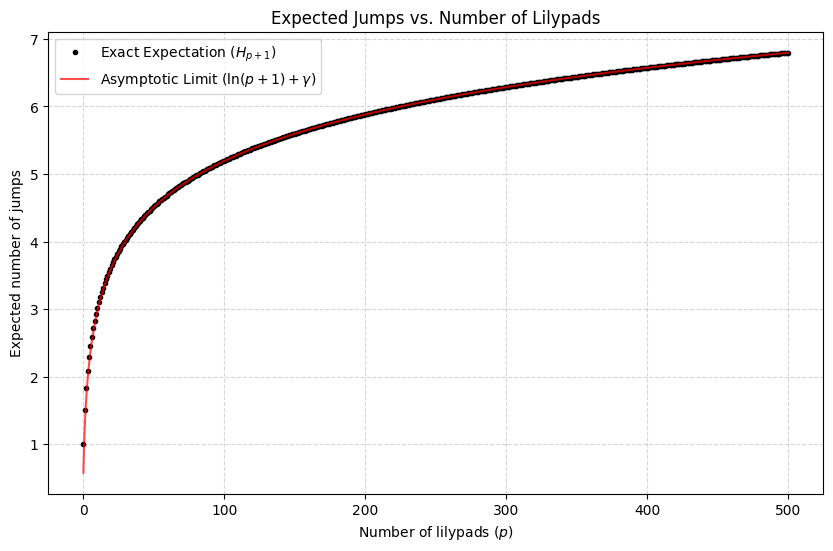

In [7]:
# Values of p to check
lowP = 0
highP = 500

# Plot points
x = range(lowP, highP + 1)
y = [expectedSteps(p) for p in x]

# Analytical approximation curve: ln(p + 1) + Euler-Mascheroni constant
x_approx = np.linspace(1, highP + 1, 1000)
y_approx = np.log(x_approx) + np.euler_gamma

pl.figure(figsize=(10, 6))
pl.plot(x, y, 'ko', markersize=3, label='Exact Expectation ($H_{p+1}$)')
pl.plot(x_approx - 1, y_approx, 'r-', alpha=0.7, label=r'Asymptotic Limit ($\ln(p+1) + \gamma$)')

pl.xlabel('Number of lilypads ($p$)')
pl.ylabel('Expected number of jumps')
pl.title('Expected Jumps vs. Number of Lilypads')
pl.legend()
pl.grid(True, linestyle='--', alpha=0.5)
pl.show()